VADER scores at the thread level

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### VADER at Conversation Level

In [ ]:
df_M_convo = pd.read_csv("M/data_sentiment/Doom_convo_final_filt.csv")
df_T_convo = pd.read_csv("T/Data/destiny2_convo_final_filt.csv")
df_E_convo = pd.read_csv("E_10+/Data/PvZGardenWarfare_convo_final_filt.csv")

df_M_convo = pd.concat([df_M_convo, pd.read_csv("M/data_sentiment/blackops3_convo_final.csv")], axis=0, ignore_index=True)
df_T_convo = pd.concat([df_T_convo, pd.read_csv("T/Data/StarWarsBattlefront_convo_final.csv")], axis=0, ignore_index=True)
df_E_convo = pd.concat([df_E_convo, pd.read_csv("E_10+/Data/splatoon_convo_final.csv")], axis=0, ignore_index=True)

list_of_corpora_convo = [df_M_convo, df_T_convo, df_E_convo]

In [ ]:
for df in list_of_corpora_convo:
    df = df.rename(columns={"sentiment_label": "VADER_sentiment_label"})

    df = df.rename(columns={"compound": "VADER_Compound"})

In [7]:
vader_map = {
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral"
}

label_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

for df in list_of_corpora_convo:
    df["VADER_sentiment_label"] = df["VADER_sentiment_label"].map(vader_map)

    df["bert_label"] = df["bert_numeric"].map(label_map)

In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_M_convo.shape)

print("\n=== Sentiment Label Distribution ===")
vader_counts_M = df_M_convo["VADER_sentiment_label"].value_counts()
vader_percent_M = df_M_convo["VADER_sentiment_label"].value_counts(normalize=True) * 100

print("\nRaw VADER Counts: \n", vader_counts_M)
print("\nPercentage:\n", vader_percent_M)

compound = df_M_convo["compound"]

print("\n=== Compound Score Statistics ===")
print(df_M_convo["compound"].describe())



=== Dataset Overview ===

Shape: (25000, 11)

=== Sentiment Label Distribution ===

Raw VADER Counts: 
 VADER_sentiment_label
Positive    15476
Negative     8578
Neutral       946
Name: count, dtype: int64

Percentage:
 VADER_sentiment_label
Positive    61.904
Negative    34.312
Neutral      3.784
Name: proportion, dtype: float64

=== Compound Score Statistics ===
count    25000.000000
mean         0.234257
std          0.770433
min         -1.000000
25%         -0.611750
50%          0.555700
75%          0.950700
max          1.000000
Name: compound, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_T_convo.shape)

print("\n=== Sentiment Label Distribution ===")
vader_counts_T = df_T_convo["VADER_sentiment_label"].value_counts()
vader_percent_T = df_T_convo["VADER_sentiment_label"].value_counts(normalize=True) * 100

print("\nRaw VADER Counts: \n", vader_counts_T)
print("\nPercentage:\n", vader_percent_T)

compound = df_T_convo["compound"]

print("\n=== Compound Score Statistics ===")
print(df_T_convo["compound"].describe())


=== Dataset Overview ===

Shape: (25000, 11)

=== Sentiment Label Distribution ===

Raw VADER Counts: 
 VADER_sentiment_label
Positive    16938
Negative     6836
Neutral      1226
Name: count, dtype: int64

Percentage:
 VADER_sentiment_label
Positive    67.752
Negative    27.344
Neutral      4.904
Name: proportion, dtype: float64

=== Compound Score Statistics ===
count    25000.000000
mean         0.347401
std          0.708815
min         -1.000000
25%         -0.239725
50%          0.687750
75%          0.964900
max          1.000000
Name: compound, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_E_convo.shape)

print("\n=== Sentiment Label Distribution ===")
vader_counts_E = df_E_convo["VADER_sentiment_label"].value_counts()
vader_percent_E = df_E_convo["VADER_sentiment_label"].value_counts(normalize=True) * 100

print("\nRaw VADER Counts: \n", vader_counts_E)
print("\nPercentage:\n", vader_percent_E)

compound = df_E_convo["compound"]

print("\n=== Compound Score Statistics ===")
print(df_E_convo["compound"].describe())


=== Dataset Overview ===

Shape: (25002, 11)

=== Sentiment Label Distribution ===

Raw VADER Counts: 
 VADER_sentiment_label
Positive    17976
Negative     6063
Neutral       959
Name: count, dtype: int64

Percentage:
 VADER_sentiment_label
Positive    71.909753
Negative    24.253940
Neutral      3.836307
Name: proportion, dtype: float64

=== Compound Score Statistics ===
count     25000.0
unique     9697.0
top           0.0
freq        540.0
Name: compound, dtype: float64


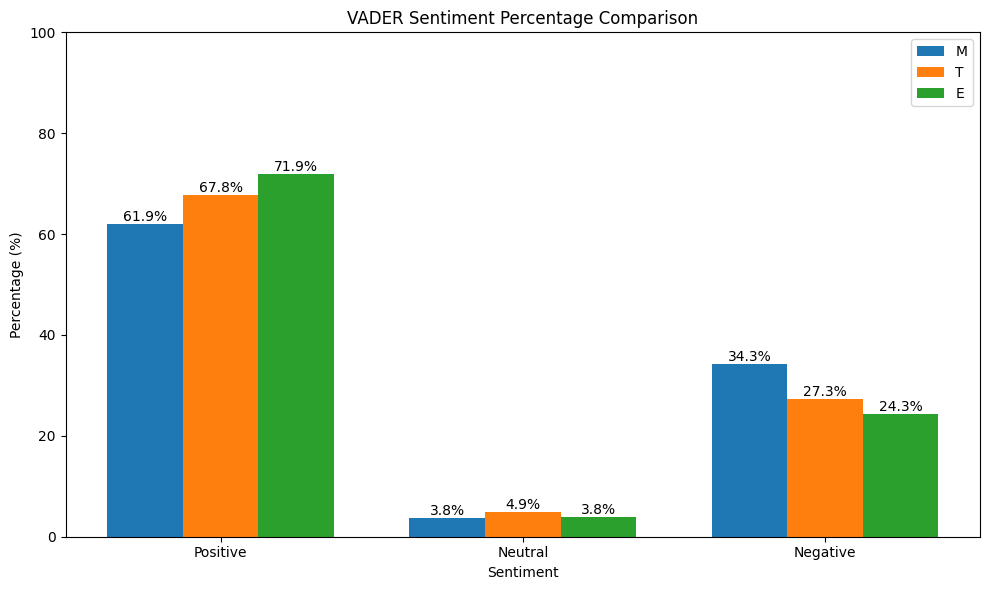

In [ ]:
labels = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(labels))
width = 0.25

percent1 = vader_percent_M.reindex(labels)
percent2 = vader_percent_T.reindex(labels)
percent3 = vader_percent_E.reindex(labels)

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width, percent1.values, width, label="M")
bars2 = plt.bar(x, percent2.values, width, label="T")
bars3 = plt.bar(x + width, percent3.values, width, label="E")

for i in range(len(labels)):
    plt.text(x[i] - width, percent1.values[i], f"{percent1.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i], percent2.values[i], f"{percent2.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i] + width, percent3.values[i], f"{percent3.values[i]:.1f}%", ha='center', va='bottom')

plt.xticks(x, labels)

plt.title(f"VADER Sentiment Percentage Comparison")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()